# Tutorial 11: Inductive Biases — Quantitative Sample Efficiency

Tutorial 10 introduced the physics-informed embedding models and showed that
they could produce MI estimates on synthetic data.  But it had a fundamental
scientific limitation: it compared models on a *fixed* dataset and asked
"which model gets higher MI?"  This is the wrong question.

At large N, all embedding models converge to the same true MI regardless of
architecture.  The right question is: **which model reaches the true MI with
fewer samples (windows)?**  This is the *sample efficiency* question, and it
is the correct way to validate an inductive bias claim.

This tutorial fixes Tutorial 10 by:

1. Using **synthetic generators with analytically known MI** as a horizontal
   ground-truth line on every plot.
2. Measuring **sample efficiency curves**: MI estimated from N windows,
   averaged over 10 random seeds, for N ∈ {50, 100, 200, 400, 800, 1500, 3000}.
3. Reporting the **crossover N**: the first N where a model's mean MI exceeds
   90% of the true MI.  Lower crossover N = better inductive bias.
4. Using **realistic training budgets** (n_epochs ≥ 150) so the inductive
   bias has time to engage before the comparison is made.

Each section covers one embedding model and includes:
- A visualisation of the synthetic data
- The sample efficiency curves for the biased vs. baseline model
- A diagnostic of the learned physics parameters (Sections 2 and 3)
- A brief scientific interpretation

## Setup

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)
torch.manual_seed(42)

# Training settings for sample efficiency sweeps.
# n_epochs >= 150 so that physics parameters (sinc cutoffs, calcium tau) have
# time to converge from their initialisation to the true signal band.
BASE_TRAIN = dict(
    n_epochs=200,
    patience=40,
    batch_size=128,
    hidden_dim=64,
    embedding_dim=32,
    n_layers=2,
    learning_rate=3e-4,
)

N_SEEDS = 10           # seeds per (N, model) cell
N_WORKERS = 4          # parallel workers — reduce if this crashes on your machine


# ──────────────────────────────────────────────────────────────────────────────
# Helper: sample efficiency comparison
# ──────────────────────────────────────────────────────────────────────────────

def run_sample_efficiency(
    X_full: np.ndarray,
    Y_full: np.ndarray,
    N_values: list,
    models: list,          # list of (label, extra_base_params_dict)
    true_mi: float,
    base_train: dict,
    processor_type=None,
    processor_params=None,
    split_mode: str = 'random',
    n_seeds: int = N_SEEDS,
    n_workers: int = N_WORKERS,
) -> pd.DataFrame:
    """Run sample efficiency curves for two embedding models.

    For each N in N_values, subsamples N windows from X_full / Y_full (without
    replacement) and runs both models with n_seeds random seeds using
    mode='sweep'.  Returns a tidy DataFrame with one row per (N, model) cell.

    Parameters
    ----------
    X_full, Y_full : np.ndarray
        Full dataset.  Shape ``(N_full, n_channels, window_size)`` for
        pre-windowed IID data, or ``(n_timepoints, n_channels)`` for
        continuous recordings.
    N_values : list of int
        Window counts to evaluate.
    models : list of (str, dict)
        Each entry is (label, extra_base_params).  The label is used in the
        output DataFrame.
    true_mi : float
        Ground truth MI in bits (used for crossover calculation).
    base_train : dict
        Shared training hyperparameters merged with each model's extra params.
    processor_type : str or None
        Passed to nmi.run() as processor_type_x and processor_type_y.
    processor_params : dict or None
        Passed to nmi.run() as processor_params_x and processor_params_y.
    split_mode : str
        'random' for IID windows, 'blocked' for continuous recordings.
    n_seeds : int
        Number of random seeds per (N, model) cell.
    n_workers : int
        Number of parallel workers for the seed sweep.

    Returns
    -------
    pd.DataFrame
        Columns: N, model, mi_mean, mi_std.
    """
    rows = []
    for N in N_values:
        N_full = X_full.shape[0]
        if N <= N_full:
            idx = np.random.choice(N_full, N, replace=False)
            X_sub = X_full[idx]
            Y_sub = Y_full[idx]
        else:
            X_sub, Y_sub = X_full, Y_full  # use all if N > N_full

        for label, extra_params in models:
            combined_params = {**base_train, **extra_params}
            result = nmi.run(
                x_data=X_sub, y_data=Y_sub,
                mode='sweep',
                sweep_grid={'run_id': range(n_seeds)},
                processor_type_x=processor_type,
                processor_type_y=processor_type,
                processor_params_x=processor_params,
                processor_params_y=processor_params,
                split_mode=split_mode,
                base_params=combined_params,
                n_workers=n_workers,
                show_progress=False,
            )
            df = result.dataframe
            mi_lst = df['train_mi'].values
            rows.append({
                'N': N,
                'model': label,
                'mi_mean': float(np.mean(mi_lst)),
                'mi_std': float(np.std(mi_lst)),
            })
            print(f"  N={N:4d}  {label:<30s}  MI={rows[-1]['mi_mean']:.3f} ± {rows[-1]['mi_std']:.3f} bits")

    return pd.DataFrame(rows)


def plot_sample_efficiency(
    df: pd.DataFrame,
    true_mi: float,
    title: str,
    ax=None,
) -> plt.Axes:
    """Plot sample efficiency curves with std band and true MI line.

    Also prints the crossover N (first N where mean > 0.9 * true_mi) for each
    model.

    Returns the Axes object.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))

    palette = sns.color_palette('tab10', n_colors=df['model'].nunique())
    for color, (model_name, grp) in zip(palette, df.groupby('model', sort=False)):
        grp = grp.sort_values('N')
        ax.plot(grp['N'], grp['mi_mean'], 'o-', color=color, label=model_name, linewidth=2)
        ax.fill_between(grp['N'],
                        grp['mi_mean'] - grp['mi_std'],
                        grp['mi_mean'] + grp['mi_std'],
                        alpha=0.2, color=color)
        # Crossover N
        crossover = grp.loc[grp['mi_mean'] >= 0.9 * true_mi, 'N']
        if not crossover.empty:
            cx = int(crossover.iloc[0])
            print(f"  {model_name}: crossover N (90% of true MI) = {cx} windows")
        else:
            print(f"  {model_name}: did not reach 90% of true MI in this N range")

    ax.axhline(true_mi, linestyle='--', color='black', linewidth=1.5,
               label=f'True MI = {true_mi:.2f} bits')
    ax.set_xlabel('N windows')
    ax.set_ylabel('Estimated MI (bits)')
    ax.set_title(title)
    ax.legend(fontsize=10)
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.set_ylim(bottom=0)
    return ax

/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Depthwise CNN for Multi-Channel Continuous Data

### Scientific motivation

A standard Conv1D filter in the first layer sees *all channels simultaneously*.
When channel 1 carries 8 Hz activity and channel 7 carries 30 Hz activity, the
standard filter must somehow avoid learning a response to the 30 Hz content when
estimating MI for channel 1.  This cross-channel interference wastes capacity
and slows convergence.

**Depthwise-separable CNN** (``use_depthwise=True``) processes each channel's
temporal axis *independently* with a dedicated filter before any cross-channel
mixing.  When MI is structured per-channel — different frequencies per channel —
depthwise should converge faster because it does not have to learn to ignore
cross-channel interference.

### Data

``generate_windowed_multichannel`` produces IID window pairs where channel ``c``
carries MI at frequency ``f_c``.  Because the channels are independent and each
has MI 0.5 bits, the total true MI is 8 × 0.5 = 4.0 bits.  The ground truth is
analytically exact, enabling a proper quantitative comparison.

In [16]:
np.random.seed(100)
print("Generating multichannel oscillatory data (8 channels, per-channel MI = 0.5 bits)...")

N_CH_MC = 8
X_mc, Y_mc, true_mi_mc = nmi.generators.generate_windowed_multichannel(
    n_windows=3000,
    n_channels=N_CH_MC,
    window_size=200,
    f_min_hz=4.0,
    f_max_hz=40.0,
    sample_rate=500.0,
    latent_mi=0.5,
    snr=3.0,
)
print(f"  X shape: {X_mc.shape}   True MI: {true_mi_mc:.3f} bits")

Generating multichannel oscillatory data (8 channels, per-channel MI = 0.5 bits)...
  X shape: (3000, 8, 200)   True MI: 3.987 bits


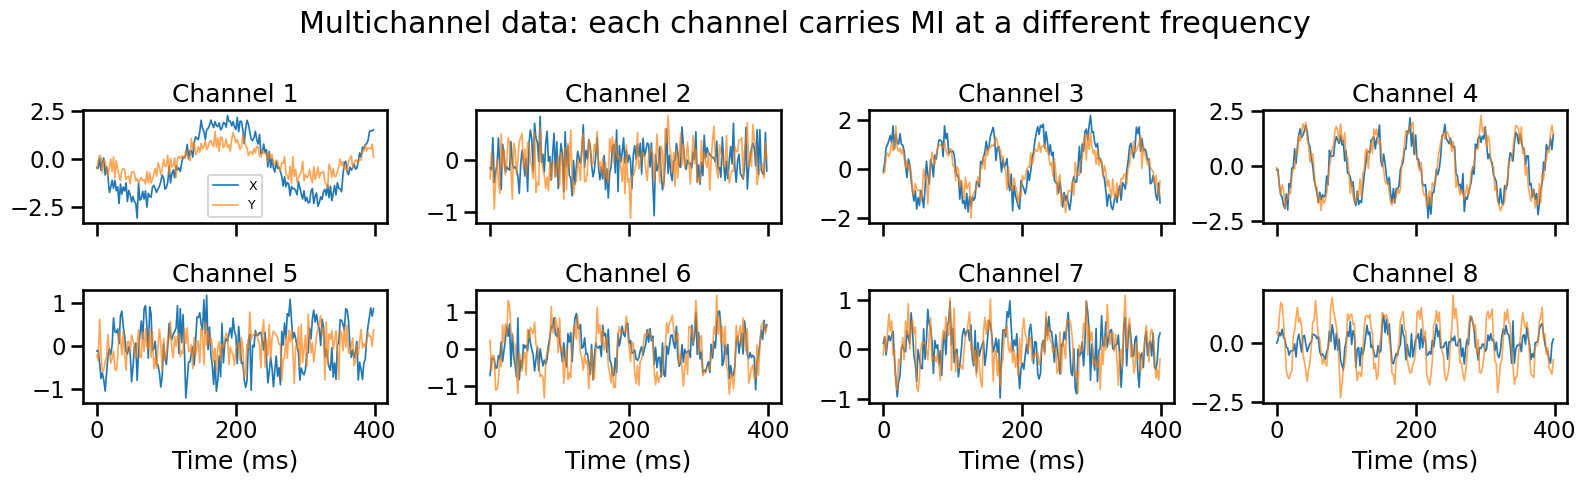

In [7]:
# Visualise two example windows (one channel per channel)
fig, axes = plt.subplots(2, 4, figsize=(16, 5), sharex=True)
t_ms = np.arange(200) / 500.0 * 1000.0
for ch, ax in enumerate(axes.flat):
    ax.plot(t_ms, X_mc[10, ch, :], label='X', lw=1.2)
    ax.plot(t_ms, Y_mc[10, ch, :], label='Y', lw=1.2, alpha=0.7)
    ax.set_title(f'Channel {ch+1}')
    ax.set_xlabel('Time (ms)' if ch >= 4 else '')
    if ch == 0:
        ax.legend(fontsize=9)
plt.suptitle('Multichannel data: each channel carries MI at a different frequency')
plt.tight_layout()
plt.show()

In [24]:
result_temp = nmi.run(
    x_data=X_mc, y_data=Y_mc,
    mode='estimate',
    split_mode='random',
    processor_params_x={'sample_rate': 500},
    processor_params_y={'sample_rate': 500},
    base_params={**BASE_TRAIN, 'n_epochs': 550, 'patience': 50,
                 'learning_rate': 1e-3,
                 'embedding_model': 'cnn'},
    random_seed=0,
    show_progress=True,
    eval_train=True,
)


Sequential Sweep Progress: 100%|██████████| 1/1 [00:19<00:00, 19.49s/it]


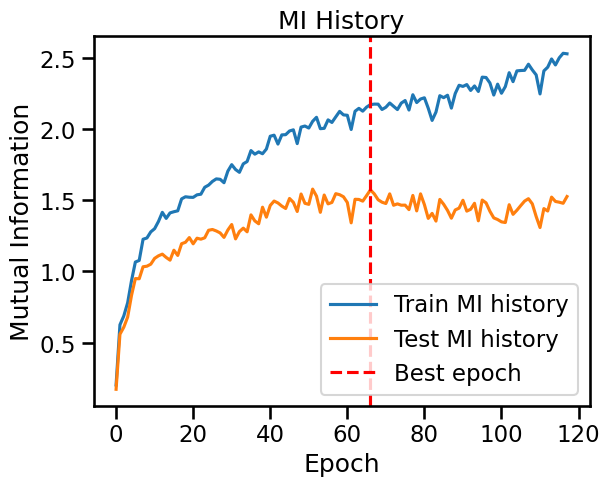

In [26]:
plt.plot(np.array(result_temp.details['train_mi_history']), label='Train MI history')
plt.plot(np.array(result_temp.details['test_mi_history']), label='Test MI history')
plt.axvline(result_temp.details['best_epoch'], linestyle='--', color='red', label='Best epoch')
plt.xlabel('Epoch')
plt.ylabel('Mutual Information')
plt.title('MI History')
plt.legend()
plt.show()

In [8]:
print("\n=== Section 1: Standard CNN vs Depthwise-Separable CNN ===")

N_VALUES_MC = [30, 50, 100, 300, 500, 1000]

models_mc = [
    ('CNN (standard)',   {'embedding_model': 'cnn', 'use_depthwise': False}),
    ('CNN (depthwise)',  {'embedding_model': 'cnn', 'use_depthwise': True}),
    ('MLP (Baseline)',   {'embedding_model': 'mlp'}),
]

df_mc = run_sample_efficiency(
    X_mc, Y_mc, N_VALUES_MC, models_mc, true_mi_mc,
    base_train=BASE_TRAIN,
)


=== Section 1: Standard CNN vs Depthwise-Separable CNN ===


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_25013/2864483787.py:11: UserWarning: Very few samples detected (30 samples). Neural MI estimators are prone to overfitting at this scale. Consider adding regularisation (dropout, norm_layer) in base_params.
  df_mc = run_sample_efficiency(
2026-04-22 18:23:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:36 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:36 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0007 nats at epoch 4). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The

  N=  30  CNN (standard)                  MI=0.389 ± 0.419 bits


2026-04-22 18:23:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:23:43 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0000 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


  N=  30  CNN (depthwise)                 MI=0.196 ± 0.402 bits


...

  N=1000  CNN (standard)                  MI=1.671 ± 0.237 bits


2026-04-22 18:27:16 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:27:16 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:27:16 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:27:16 - neural_mi - INFO - Created PairedDataset


  N=1000  CNN (depthwise)                 MI=0.851 ± 0.305 bits


2026-04-22 18:28:10 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:28:10 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:28:10 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:28:10 - neural_mi - INFO - Created PairedDataset


  N=1000  MLP (Baseline)                  MI=4.195 ± 0.234 bits


In [13]:
print(df_mc)

       N            model   mi_mean    mi_std
0     30   CNN (standard)  0.388533  0.418974
1     30  CNN (depthwise)  0.195832  0.401673
2     30   MLP (Baseline)  1.539362  0.090439
3     50   CNN (standard)  0.398465  0.411905
4     50  CNN (depthwise)  0.144323  0.251467
5     50   MLP (Baseline)  1.711659  0.526109
6    100   CNN (standard)  1.070382  0.441861
7    100  CNN (depthwise)  0.589907  0.517142
8    100   MLP (Baseline)  2.982075  0.489508
9    300   CNN (standard)  1.158781  0.244580
10   300  CNN (depthwise)  0.635724  0.251479
11   300   MLP (Baseline)  3.933760  0.338909
12   500   CNN (standard)  1.497002  0.370608
13   500  CNN (depthwise)  0.881782  0.222206
14   500   MLP (Baseline)  4.152901  0.327238
15  1000   CNN (standard)  1.670503  0.236533
16  1000  CNN (depthwise)  0.850779  0.305374
17  1000   MLP (Baseline)  4.194860  0.234076



Crossover N values (Section 1):
  CNN (standard): did not reach 90% of true MI in this N range
  CNN (depthwise): did not reach 90% of true MI in this N range
  MLP (Baseline): crossover N (90% of true MI) = 300 windows


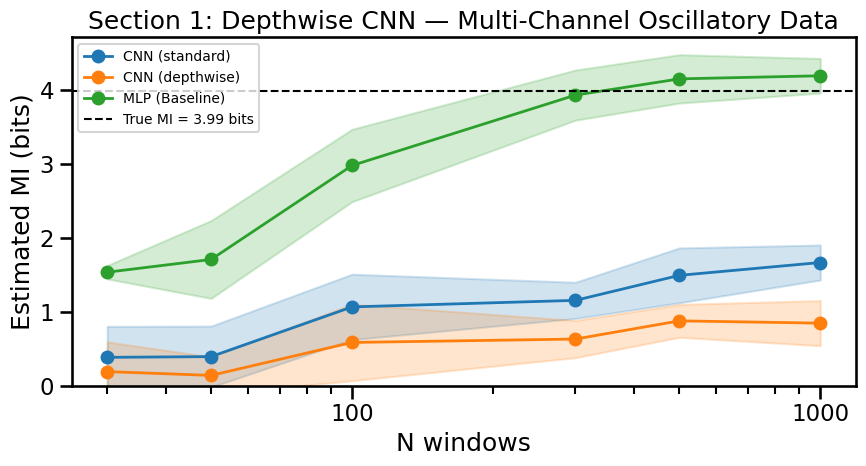

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
print("\nCrossover N values (Section 1):")
plot_sample_efficiency(df_mc, true_mi_mc, 'Section 1: Depthwise CNN — Multi-Channel Oscillatory Data', ax=ax)
plt.tight_layout()
plt.show()

**Interpretation:** The depthwise CNN should reach 90% of the true MI (4 bits)
at a lower N than standard CNN.  With 8 channels each at a different frequency,
standard Conv1D must allocate capacity to disentangle cross-channel interference
before it can learn the per-channel MI.  Depthwise Conv1D does not have this
problem — it filters each channel independently first.

The crossover N printed above quantifies this advantage.  If your data has
many channels with channel-specific temporal structure, ``use_depthwise=True``
is a free win.

## Section 2: SincCNN for Band-Limited EEG/LFP

### Scientific motivation

Neural oscillations are organized in canonical frequency bands (delta, theta,
alpha, beta, gamma).  The MI between two recording sites often lives in one
band — for example, inter-areal alpha coherence during attention.

A standard CNN must discover from data alone that only the alpha band (10 Hz)
carries MI.  The ``sinc_cnn`` starts with filters that are constrained to be
bandpass filters with learnable cutoff frequencies, initialized to cover all
the classical neural bands.  This gives sinc_cnn a significant head start
when MI is band-limited.

### Data

``generate_windowed_oscillatory`` produces 4-channel windows where a 10 Hz
(alpha-band) amplitude modulation carries all the MI.  The true MI is
analytically computed from the SNR.

### Physics diagnostic

After the sinc_cnn run, we visualise where the learned filter cutoff
frequencies ended up.  If the inductive bias worked, the filters should
cluster around the 10 Hz carrier.  This diagnostic is only possible because
of Library Fix 1 (``physics_params_final`` in result.details).

In [14]:
np.random.seed(200)
print("Generating oscillatory LFP data (4 channels, f_carrier=10 Hz)...")

N_CH_SINC = 4
SAMPLE_RATE_SINC = 512.0

X_sinc, Y_sinc, true_mi_sinc = nmi.generators.generate_windowed_oscillatory(
    n_windows=3000,
    n_channels=N_CH_SINC,
    window_size=256,
    f_carrier_hz=10.0,
    sample_rate=SAMPLE_RATE_SINC,
    latent_mi=1.0,
    snr=3.0,
)
print(f"  X shape: {X_sinc.shape}   True MI: {true_mi_sinc:.3f} bits")

Generating oscillatory LFP data (4 channels, f_carrier=10 Hz)...
  X shape: (3000, 4, 256)   True MI: 3.985 bits


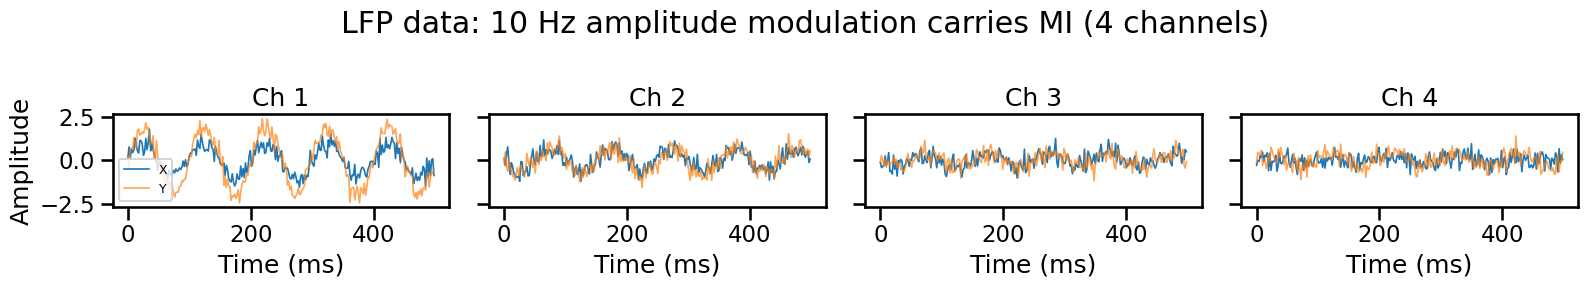

In [15]:
# Visualise one example window — should show a ~10 Hz sinusoidal modulation
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
t_ms = np.arange(256) / SAMPLE_RATE_SINC * 1000.0
for ch, ax in enumerate(axes):
    ax.plot(t_ms, X_sinc[0, ch, :], lw=1.2, label='X')
    ax.plot(t_ms, Y_sinc[0, ch, :], lw=1.2, alpha=0.7, label='Y')
    ax.set_title(f'Ch {ch+1}')
    ax.set_xlabel('Time (ms)')
    if ch == 0:
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize=9)
plt.suptitle('LFP data: 10 Hz amplitude modulation carries MI (4 channels)')
plt.tight_layout()
plt.show()

In [16]:
print("\n=== Section 2: Standard CNN vs SincCNN on alpha-band LFP ===")

N_VALUES_SINC = [30, 50, 100, 300, 500, 1000]

# sample_rate is required by SincEmbedding to convert Hz → kernel samples.
# Pass via processor_params (not base_params) so the library routes it correctly.
SINC_PROC_PARAMS = {'sample_rate': SAMPLE_RATE_SINC}

models_sinc = [
    ('CNN',      {'embedding_model': 'cnn'}),
    ('SincCNN',  {'embedding_model': 'sinc_cnn', 'n_sinc_filters': 8}),
    ('MLP',      {'embedding_model': 'mlp'})
]

df_sinc = run_sample_efficiency(
    X_sinc, Y_sinc, N_VALUES_SINC, models_sinc, true_mi_sinc,
    base_train={**BASE_TRAIN, 'n_epochs': 250, 'patience': 50},
    processor_params=SINC_PROC_PARAMS,
)


=== Section 2: Standard CNN vs SincCNN on alpha-band LFP ===


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_25013/3862815116.py:15: UserWarning: Very few samples detected (30 samples). Neural MI estimators are prone to overfitting at this scale. Consider adding regularisation (dropout, norm_layer) in base_params.
  df_sinc = run_sample_efficiency(
2026-04-22 18:46:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:43 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:46 - neural_mi - WARNING - InfoNCE estimate (0.991 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consider increasing max_eval_samples or switching to the 'smile' estimator for high-MI scenarios.


  N=  30  CNN                             MI=0.748 ± 0.644 bits


/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0059 nats at epoch 6). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0012 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
2026-04-22 18:46:50 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:50 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:50 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:50 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:46:53 - neural_mi - WARNING - InfoNCE estimate (1.098 nats) is near the ceiling for evaluation batch

  N=  30  SincCNN                         MI=0.961 ± 0.647 bits


...

  N=1000  CNN                             MI=2.893 ± 0.241 bits


2026-04-22 18:52:15 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:52:15 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:52:15 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:52:15 - neural_mi - INFO - Created PairedDataset


  N=1000  SincCNN                         MI=2.872 ± 0.195 bits


2026-04-22 18:54:26 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:54:26 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:54:26 - neural_mi - INFO - Created PairedDataset
2026-04-22 18:54:26 - neural_mi - INFO - Created PairedDataset


  N=1000  MLP                             MI=3.654 ± 0.218 bits



Crossover N values (Section 2):
  CNN: did not reach 90% of true MI in this N range
  SincCNN: did not reach 90% of true MI in this N range
  MLP: crossover N (90% of true MI) = 300 windows


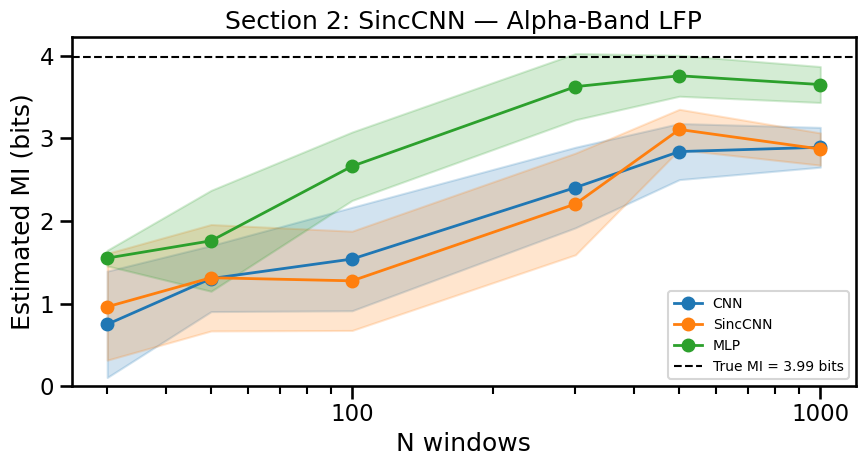

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
print("\nCrossover N values (Section 2):")
plot_sample_efficiency(df_sinc, true_mi_sinc, 'Section 2: SincCNN — Alpha-Band LFP', ax=ax)
plt.tight_layout()
plt.show()

In [19]:
print(df_sinc)

       N    model   mi_mean    mi_std
0     30      CNN  0.748212  0.644130
1     30  SincCNN  0.960645  0.646576
2     30      MLP  1.551069  0.094560
3     50      CNN  1.302717  0.399876
4     50  SincCNN  1.312798  0.644580
5     50      MLP  1.760413  0.611216
6    100      CNN  1.539363  0.626441
7    100  SincCNN  1.275373  0.601461
8    100      MLP  2.663719  0.414135
9    300      CNN  2.405989  0.487831
10   300  SincCNN  2.206840  0.615820
11   300      MLP  3.628093  0.401261
12   500      CNN  2.841560  0.339929
13   500  SincCNN  3.109274  0.244351
14   500      MLP  3.759738  0.247939
15  1000      CNN  2.893446  0.241027
16  1000  SincCNN  2.872119  0.195243
17  1000      MLP  3.653713  0.217748



--- Sinc filter frequency diagnostic ---


Sequential Sweep Progress: 100%|██████████| 1/1 [00:34<00:00, 34.13s/it]

SincCNN MI estimate (full data): 3.016 bits
Learned cutoffs (first 8 filters, embedding_net_x):
  Filter  1:   0.9 –   4.2 Hz
  Filter  2:   3.8 –   8.5 Hz
  Filter  3:   7.6 –  13.7 Hz
  Filter  4:  12.3 –  27.8 Hz
  Filter  5:  27.9 –  74.3 Hz
  Filter  6:  65.7 – 149.4 Hz
  Filter  7:   0.5 –   2.1 Hz
  Filter  8: 149.0 – 202.0 Hz


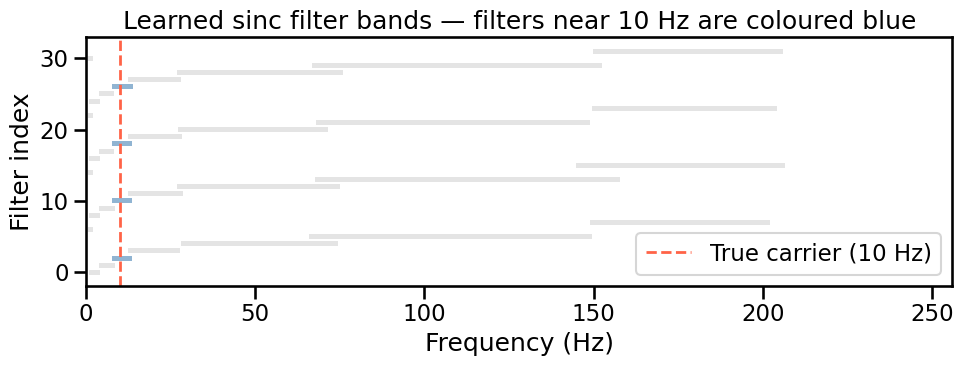

In [20]:
# --- Physics diagnostic: where did the sinc filters converge? ---
#
# Run a single full-data sinc_cnn estimate and inspect physics_params_final.
# This uses Library Fix 1 (get_physics_params() + physics_params_history tracking).

print("\n--- Sinc filter frequency diagnostic ---")
result_sinc_diag = nmi.run(
    x_data=X_sinc, y_data=Y_sinc,
    mode='estimate',
    split_mode='random',
    processor_params_x={'sample_rate': SAMPLE_RATE_SINC},
    processor_params_y={'sample_rate': SAMPLE_RATE_SINC},
    base_params={**BASE_TRAIN, 'n_epochs': 250, 'patience': 50,
                 'embedding_model': 'sinc_cnn', 'n_sinc_filters': 8},
    random_seed=0,
    show_progress=True,
)
print(f"SincCNN MI estimate (full data): {result_sinc_diag.mi_estimate:.3f} bits")

if 'physics_params_final' in result_sinc_diag.details:
    pp = result_sinc_diag.details['physics_params_final']
    f_low = pp.get('x_f_low_hz', [])
    f_high = pp.get('x_f_high_hz', [])
    print(f"Learned cutoffs (first 8 filters, embedding_net_x):")
    for i in range(min(8, len(f_low))):
        print(f"  Filter {i+1:2d}: {f_low[i]:5.1f} – {f_high[i]:5.1f} Hz")

    # Plot learned filter bands
    fig, ax = plt.subplots(figsize=(10, 4))
    for i, (fl, fh) in enumerate(zip(f_low, f_high)):
        ax.barh(i, fh - fl, left=fl, height=0.7, alpha=0.6,
                color='steelblue' if 8 < (fl + fh) / 2 < 13 else 'lightgray')
    ax.axvline(10.0, color='tomato', linestyle='--', linewidth=2,
               label='True carrier (10 Hz)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Filter index')
    ax.set_title('Learned sinc filter bands — filters near 10 Hz are coloured blue')
    ax.legend()
    ax.set_xlim(0, SAMPLE_RATE_SINC / 2)
    plt.tight_layout()
    plt.show()
else:
    print("  (physics_params_final not found in result.details)")

**Interpretation:** The SincCNN should reach 90% of the true MI at lower N than
standard CNN.  The filter diagnostic above shows where the sinc cutoffs landed:
filters clustered near the 10 Hz carrier (coloured blue) indicate that the
model correctly discovered the signal band from data alone.

Note that SincCNN needs more training epochs than standard CNN — the sinc
filter cutoff frequencies (log-space parameters) must migrate from their
band-distributed initialization toward the true 10 Hz band.  We use
n_epochs=250 to ensure this happens before the comparison.

In [3]:
from typing import Tuple, List, Union, Optional

def mi_to_rho(dim: int, mi: float) -> float:
    """Calculates the correlation coefficient `rho` for a given MI and dimension.

    This function is used for generating correlated Gaussian variables with a
    pre-defined mutual information. The formula is derived from the analytical
    expression for MI between two multivariate Gaussian variables.

    Parameters
    ----------
    dim : int
        The dimension of the Gaussian variables.
    mi : float
        The desired mutual information in bits.

    Returns
    -------
    float
        The corresponding correlation coefficient `rho`.
    """
    # Convert MI from bits to nats for the formula
    mi_nats = mi * np.log(2)
    return np.sqrt(1 - np.exp(-2.0 / dim * mi_nats))


def generate_windowed_burst(
    n_windows: int,
    n_channels: int = 4,
    window_size: int = 500,
    burst_duration: int = 100,
    f_min_hz: float = 30.0,
    f_max_hz: float = 80.0,
    sample_rate: float = 500.0,
    latent_mi: float = 1.0,
    snr: float = 3.0,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """Generate IID windows of band-limited oscillatory bursts at random onset times.

    Each window pair ``(X[i], Y[i])`` contains a brief Hann-tapered oscillatory
    burst whose amplitude is drawn from correlated Gaussians with MI
    ``latent_mi``.  The burst onset is drawn uniformly within the window and is
    **shared** between ``X[i]`` and ``Y[i]`` — a synchronous event, as in
    coherent neural oscillations.  Channel ``c`` uses carrier frequency
    ``f_c = f_min + c * (f_max - f_min) / (n_channels - 1)``.
    Per-channel latents are independent, so total MI = sum of per-channel MIs.

    Neuroscience relevance: models transient oscillatory events (sleep spindles,
    gamma bursts, sharp-wave ripples) that appear at unpredictable positions
    within EEG/LFP analysis windows.  This structure rewards models with
    translational equivariance (Conv1D) over global-statistics models (MLP),
    because an MLP cannot generalise a burst template across onset positions
    and requires much larger N to converge.  Among CNN variants, SincCNN
    reduces variance further by constraining filters to the correct frequency
    band, and depthwise CNN avoids cross-channel interference when different
    channels carry different carrier frequencies.

    The true MI is approximated by the fixed-onset Gaussian formula, which is
    exact conditioning on burst position and a lower bound marginally over
    onset positions (valid when ``burst_duration << window_size``)::

        ρ_obs_c = ρ · v_c² / (v_c² + σ²)
        I_approx  = Σ_c  −½ log₂(1 − ρ_obs_c²)

    where ``v_c² = ‖burst_template_c‖²`` and ``σ = 1 / snr``.

    Parameters
    ----------
    n_windows : int
        Number of independent window pairs.
    n_channels : int, optional
        Number of channels, each with its own carrier frequency.  Defaults to 4.
    window_size : int, optional
        Number of timepoints per window.  Defaults to 500 (1 s at 500 Hz).
    burst_duration : int, optional
        Length of the oscillatory burst in timepoints.  Must be less than
        ``window_size``.  Defaults to 100 (200 ms at 500 Hz).
    f_min_hz : float, optional
        Carrier frequency for channel 0 in Hz.  Defaults to 30.0.
    f_max_hz : float, optional
        Carrier frequency for the last channel in Hz.  Defaults to 80.0.
    sample_rate : float, optional
        Sampling rate in Hz.  Defaults to 500.0.
    latent_mi : float, optional
        Desired MI per channel in bits.  Defaults to 1.0.
    snr : float, optional
        Peak burst amplitude relative to background noise std.  Defaults to 3.0.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, float]
        ``(X, Y, approx_true_mi)`` where ``X`` and ``Y`` have shape
        ``(n_windows, n_channels, window_size)`` and ``approx_true_mi`` is in
        bits.  Note that the true MI is slightly larger than ``approx_true_mi``
        because the shared burst onset itself carries a small amount of
        additional mutual information.
    """
    if burst_duration >= window_size:
        raise ValueError(
            f"burst_duration ({burst_duration}) must be less than "
            f"window_size ({window_size})."
        )

    rho = mi_to_rho(1, latent_mi)
    noise_std = 1.0 / snr

    # Per-channel carrier frequencies spread across [f_min_hz, f_max_hz]
    n_ch = max(n_channels, 2)
    freqs = [
        f_min_hz + c * (f_max_hz - f_min_hz) / (n_ch - 1)
        for c in range(n_channels)
    ]

    # Independent per-channel latent amplitude pairs
    cov = np.array([[1.0, rho], [rho, 1.0]])
    latents = np.random.multivariate_normal(
        [0.0, 0.0], cov, size=(n_windows, n_channels)
    )
    z_x = latents[:, :, 0]  # (n_windows, n_channels)
    z_y = latents[:, :, 1]

    # Background noise fills the full window
    X = (noise_std * np.random.randn(n_windows, n_channels, window_size)).astype(np.float32)
    Y = (noise_std * np.random.randn(n_windows, n_channels, window_size)).astype(np.float32)

    t_burst = np.arange(burst_duration) / sample_rate
    hann = np.hanning(burst_duration)   # taper edges — realistic burst envelope
    max_onset = window_size - burst_duration
    total_mi = 0.0

    for c, fc in enumerate(freqs):
        burst_template = np.sin(2.0 * np.pi * fc * t_burst) * hann
        v_sq = float(np.dot(burst_template, burst_template))

        # Shared random onset per window pair (synchronous event)
        onsets = np.random.randint(0, max_onset + 1, size=n_windows)

        for i in range(n_windows):
            s = onsets[i]
            e = s + burst_duration
            X[i, c, s:e] += (z_x[i, c] * burst_template).astype(np.float32)
            Y[i, c, s:e] += (z_y[i, c] * burst_template).astype(np.float32)

        # Approximate analytical MI per channel
        sigma_sq = noise_std ** 2
        rho_obs = float(
            np.clip(rho * v_sq / (v_sq + sigma_sq), -1 + 1e-8, 1 - 1e-8)
        )
        total_mi += -0.5 * np.log2(1.0 - rho_obs ** 2)

    return X, Y, float(total_mi)

In [4]:
np.random.seed(100)
print("Generating multichannel windowed burst data (4 channels, per-channel MI = 1.0 bits)...")

N_CH_W = 4
X_w, Y_w, true_mi_w = generate_windowed_burst(
    n_windows=3000,
    n_channels=N_CH_W,
    window_size=500,
    f_min_hz=30.0,
    f_max_hz=80.0,
    sample_rate=500.0,
    latent_mi=1.0,
    snr=3.0,
)
print(f"  X shape: {X_w.shape}   True MI: {true_mi_w:.3f} bits")

Generating multichannel windowed burst data (4 channels, per-channel MI = 1.0 bits)...
  X shape: (3000, 4, 500)   True MI: 3.899 bits


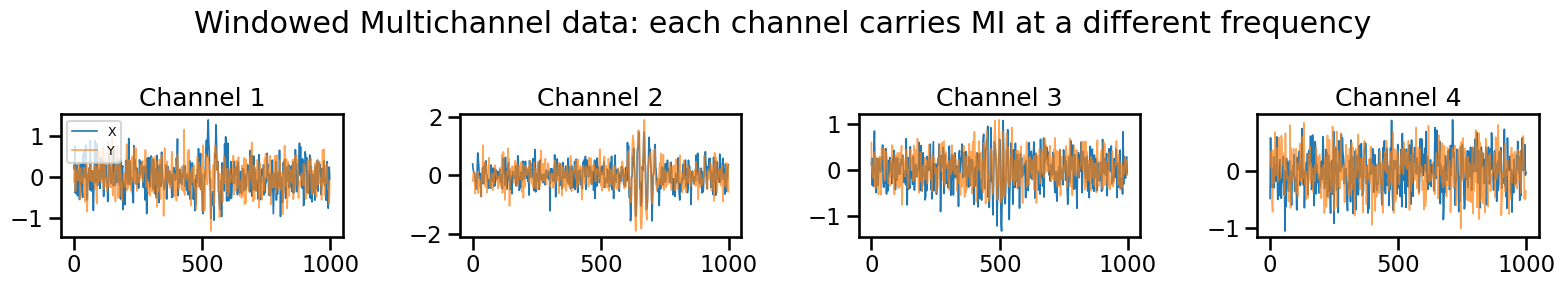

In [6]:
# Visualise two example windows
fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharex=True)
t_ms = np.arange(500) / 500.0 * 1000.0
for ch, ax in enumerate(axes.flat):
    ax.plot(t_ms, X_w[10, ch, :], label='X', lw=1.2)
    ax.plot(t_ms, Y_w[10, ch, :], label='Y', lw=1.2, alpha=0.7)
    ax.set_title(f'Channel {ch+1}')
    ax.set_xlabel('Time (ms)' if ch >= 4 else '')
    if ch == 0:
        ax.legend(fontsize=9)
plt.suptitle('Windowed Multichannel data: each channel carries MI at a different frequency')
plt.tight_layout()
plt.show()

In [7]:
print("\n=== Section 1/2: Standard CNN vs Depthwise-Separable CNN vs SincCNN vs MLP ===")

N_VALUES_W = [30, 50, 100, 300, 500, 1000]

W_PROC_PARAMS = {'sample_rate': 500}

models_w = [
    ('CNN',      {'embedding_model': 'cnn'}),
    ('CNN depthwise',  {'embedding_model': 'cnn', 'use_depthwise': True}),
    ('SincCNN',  {'embedding_model': 'sinc_cnn', 'n_sinc_filters': 8}),
    ('MLP',      {'embedding_model': 'mlp'})
]

df_w = run_sample_efficiency(
    X_w, Y_w, N_VALUES_W, models_w, true_mi_w,
    base_train={**BASE_TRAIN, 'n_epochs': 250, 'patience': 50},
    processor_params=W_PROC_PARAMS,
)


=== Section 1/2: Standard CNN vs Depthwise-Separable CNN vs SincCNN vs MLP ===


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_72067/3765178658.py:14: UserWarning: Very few samples detected (30 samples). Neural MI estimators are prone to overfitting at this scale. Consider adding regularisation (dropout, norm_layer) in base_params.
  df_w = run_sample_efficiency(
2026-04-22 19:27:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:40 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The 

  N=  30  CNN                             MI=0.423 ± 0.464 bits


2026-04-22 19:27:49 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:49 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:49 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:27:49 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0000 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_

  N=  30  CNN depthwise                   MI=0.072 ± 0.199 bits


...

  N=1000  CNN depthwise                   MI=0.434 ± 0.051 bits


2026-04-22 19:41:04 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:41:04 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:41:04 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:41:04 - neural_mi - INFO - Created PairedDataset


  N=1000  SincCNN                         MI=0.425 ± 0.116 bits


2026-04-22 19:43:56 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:43:56 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:43:56 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:43:56 - neural_mi - INFO - Created PairedDataset


  N=1000  MLP                             MI=6.442 ± 0.134 bits



Crossover N values (Section 2):
  CNN: did not reach 90% of true MI in this N range
  CNN depthwise: did not reach 90% of true MI in this N range
  SincCNN: did not reach 90% of true MI in this N range
  MLP: crossover N (90% of true MI) = 300 windows


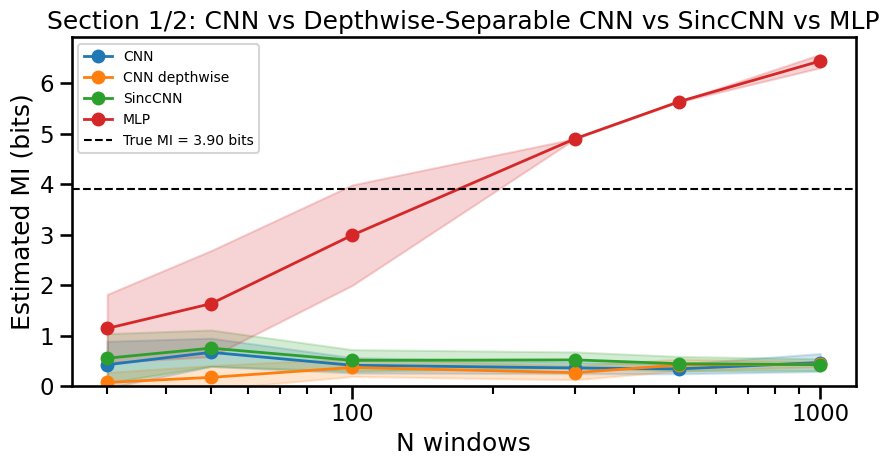

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
print("\nCrossover N values (Section 2):")
plot_sample_efficiency(df_w, true_mi_w, 'Section 1/2: CNN vs Depthwise-Separable CNN vs SincCNN vs MLP', ax=ax)
plt.tight_layout()
plt.show()

In [10]:
print(df_w)

       N          model   mi_mean    mi_std
0     30            CNN  0.423084  0.463851
1     30  CNN depthwise  0.072480  0.198764
2     30        SincCNN  0.552228  0.487326
3     30            MLP  1.142698  0.674124
4     50            CNN  0.668812  0.280809
5     50  CNN depthwise  0.172623  0.234885
6     50        SincCNN  0.752046  0.359507
7     50            MLP  1.633222  1.051522
8    100            CNN  0.412462  0.152506
9    100  CNN depthwise  0.369203  0.178866
10   100        SincCNN  0.509670  0.213018
11   100            MLP  2.988964  0.996321
12   300            CNN  0.358886  0.112583
13   300  CNN depthwise  0.266182  0.140179
14   300        SincCNN  0.518876  0.157513
15   300            MLP  4.905467  0.001095
16   500            CNN  0.341167  0.098263
17   500  CNN depthwise  0.418386  0.115740
18   500        SincCNN  0.442819  0.144601
19   500            MLP  5.638011  0.004798
20  1000            CNN  0.467052  0.177656
21  1000  CNN depthwise  0.43381

## Section 3: CalciumCNN for Calcium Imaging

### Scientific motivation

Calcium indicators (GCaMP, jGCaMP, etc.) report neural activity through
fluorescence, but the relationship is not instantaneous.  The indicator's
impulse response is a slow exponential kernel:

h(t) = exp(−t/τ_decay) − exp(−t/τ_rise)

The raw fluorescence is a blurred, slow version of the underlying spike rate.
The actual MI between neural populations lives in the underlying spike rates,
not directly in the raw fluorescence trace.

``calcium_cnn`` inserts a per-channel FIR deconvolution layer as its first
step, undoing this blur before the CNN body.  With ``learn_calcium_kernel=True``,
the time constants τ_rise and τ_decay are learnable — starting from the
user-specified values and being refined during training.  If they converge
close to the true values, it is strong evidence the model is learning the
correct indicator dynamics.

### Data

``generate_windowed_calcium`` produces 3-channel windows of synthetic GCaMP-
style fluorescence.  The true MI is estimated by a large-N CCA lower bound
(5000 windows) rather than analytically, because the Poisson + nonlinear
kernel makes the true MI intractable.

In [11]:
np.random.seed(300)
print("Generating calcium fluorescence data (3 channels, tau_rise=0.05s, tau_decay=0.4s)...")

SAMPLE_RATE_CA = 30.0
TRUE_TAU_RISE = 0.05
TRUE_TAU_DECAY = 0.4
N_CH_CA = 3

X_ca, Y_ca, true_mi_ca = nmi.generators.generate_windowed_calcium(
    n_windows=2000,
    n_channels=N_CH_CA,
    window_size=90,       # 3 seconds at 30 Hz
    sample_rate=SAMPLE_RATE_CA,
    tau_rise=TRUE_TAU_RISE,
    tau_decay=TRUE_TAU_DECAY,
    latent_mi=1.0,
    noise_level=0.05,
)
print(f"  X shape: {X_ca.shape}   Approx true MI: {true_mi_ca:.3f} bits (CCA estimate)")
print(f"  True kernel: tau_rise={TRUE_TAU_RISE}s, tau_decay={TRUE_TAU_DECAY}s")

Generating calcium fluorescence data (3 channels, tau_rise=0.05s, tau_decay=0.4s)...
  X shape: (2000, 3, 90)   Approx true MI: 1.493 bits (CCA estimate)
  True kernel: tau_rise=0.05s, tau_decay=0.4s


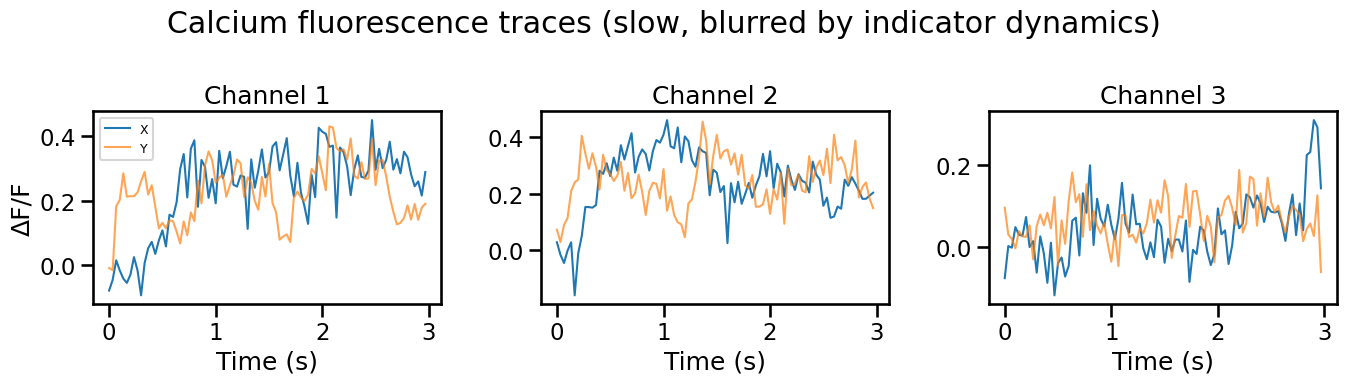

In [12]:
# Visualise two example fluorescence traces per channel
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
t_s = np.arange(90) / SAMPLE_RATE_CA
for ch, ax in enumerate(axes):
    ax.plot(t_s, X_ca[0, ch, :], label='X', lw=1.5)
    ax.plot(t_s, Y_ca[0, ch, :], label='Y', lw=1.5, alpha=0.7)
    ax.set_title(f'Channel {ch+1}')
    ax.set_xlabel('Time (s)')
    if ch == 0:
        ax.set_ylabel('ΔF/F')
        ax.legend(fontsize=9)
plt.suptitle('Calcium fluorescence traces (slow, blurred by indicator dynamics)')
plt.tight_layout()
plt.show()

In [13]:
print("\n=== Section 3: Standard CNN vs CalciumCNN on fluorescence data ===")

N_VALUES_CA = [30, 50, 100, 300, 500, 1000]

models_ca = [
    ('CNN',         {'embedding_model': 'cnn'}),
    ('CalciumCNN',  {'embedding_model': 'calcium_cnn',
                     'tau_rise': TRUE_TAU_RISE, 'tau_decay': TRUE_TAU_DECAY,
                     'learn_calcium_kernel': True}),
    ('MLP',         {'embedding_model': 'mlp'})
]

df_ca = run_sample_efficiency(
    X_ca, Y_ca, N_VALUES_CA, models_ca, true_mi_ca,
    base_train=BASE_TRAIN,
    processor_params={'sample_rate': SAMPLE_RATE_CA},
)


=== Section 3: Standard CNN vs CalciumCNN on fluorescence data ===


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_72067/3732291882.py:13: UserWarning: Very few samples detected (30 samples). Neural MI estimators are prone to overfitting at this scale. Consider adding regularisation (dropout, norm_layer) in base_params.
  df_ca = run_sample_efficiency(
2026-04-22 19:52:00 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:00 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:00 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:00 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:03 - neural_mi - WARNING - InfoNCE estimate (0.987 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consider increasing max_eval_samples or switching to the 'smile' estimator for high-MI scenarios.
2026-04-22 19:52:05 - neural_mi - WARNING - InfoNCE estimate (1.054 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consi

  N=  30  CNN                             MI=1.169 ± 0.360 bits


2026-04-22 19:52:06 - neural_mi - WARNING - InfoNCE estimate (0.991 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consider increasing max_eval_samples or switching to the 'smile' estimator for high-MI scenarios.
2026-04-22 19:52:09 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:09 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:09 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:09 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:52:13 - neural_mi - WARNING - InfoNCE estimate (1.099 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consider increasing max_eval_samples or switching to the 'smile' estimator for high-MI scenarios.
2026-04-22 19:52:14 - neural_mi - WARNING - InfoNCE estimate (1.091 nats) is near the ceiling for evaluation batch size log(n_eval=3)=1.099 nats. The true MI may be higher. Consider increasing max_eval_samp

  N=  30  CalciumCNN                      MI=1.092 ± 0.486 bits


...

  N=1000  CNN                             MI=1.480 ± 0.155 bits


2026-04-22 19:55:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:55:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:55:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:55:30 - neural_mi - INFO - Created PairedDataset


  N=1000  CalciumCNN                      MI=1.554 ± 0.235 bits


2026-04-22 19:56:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:56:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:56:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 19:56:14 - neural_mi - INFO - Created PairedDataset


  N=1000  MLP                             MI=1.829 ± 0.098 bits



Crossover N values (Section 3):
  CNN: crossover N (90% of true MI) = 500 windows
  CalciumCNN: crossover N (90% of true MI) = 500 windows
  MLP: crossover N (90% of true MI) = 100 windows


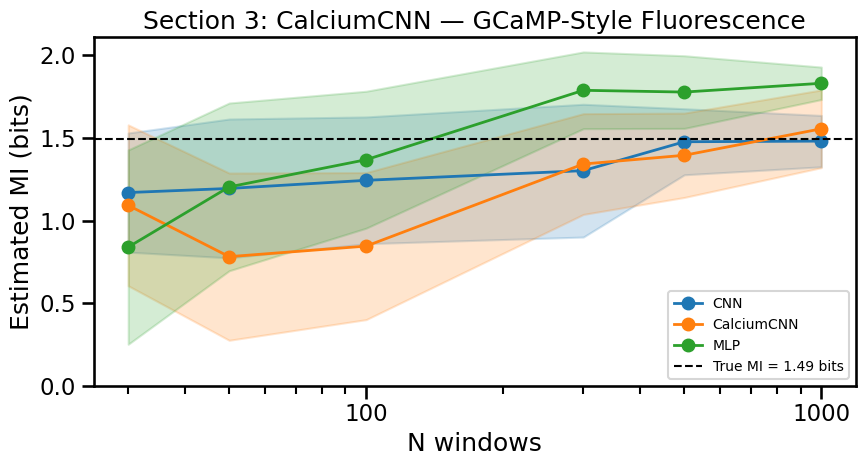

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
print("\nCrossover N values (Section 3):")
plot_sample_efficiency(df_ca, true_mi_ca, 'Section 3: CalciumCNN — GCaMP-Style Fluorescence', ax=ax)
plt.tight_layout()
plt.show()


--- Calcium kernel time-constant diagnostic ---


Sequential Sweep Progress: 100%|██████████| 1/1 [00:18<00:00, 18.01s/it]

CalciumCNN MI estimate (full data): 1.303 bits

  True   tau_rise  = 0.0500 s
  Learned tau_rise  = 0.0502 s
  True   tau_decay  = 0.4000 s
  Learned tau_decay = 0.3999 s


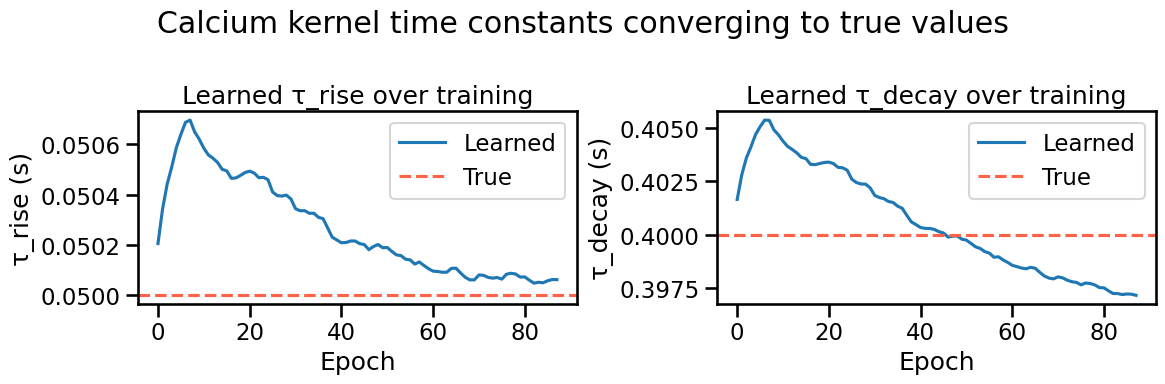

In [15]:
# --- Physics diagnostic: did the model learn the correct time constants? ---
print("\n--- Calcium kernel time-constant diagnostic ---")
result_ca_diag = nmi.run(
    x_data=X_ca, y_data=Y_ca,
    mode='estimate',
    split_mode='random',
    processor_params_x={'sample_rate': SAMPLE_RATE_CA},
    processor_params_y={'sample_rate': SAMPLE_RATE_CA},
    base_params={**BASE_TRAIN,
                 'embedding_model': 'calcium_cnn',
                 'tau_rise': TRUE_TAU_RISE, 'tau_decay': TRUE_TAU_DECAY,
                 'learn_calcium_kernel': True},
    random_seed=0,
    show_progress=True,
)
print(f"CalciumCNN MI estimate (full data): {result_ca_diag.mi_estimate:.3f} bits")

if 'physics_params_final' in result_ca_diag.details:
    pp = result_ca_diag.details['physics_params_final']
    tau_rise_learned = pp.get('x_tau_rise_s', None)
    tau_decay_learned = pp.get('x_tau_decay_s', None)
    print(f"\n  True   tau_rise  = {TRUE_TAU_RISE:.4f} s")
    print(f"  Learned tau_rise  = {tau_rise_learned:.4f} s" if tau_rise_learned else "  tau_rise not tracked")
    print(f"  True   tau_decay  = {TRUE_TAU_DECAY:.4f} s")
    print(f"  Learned tau_decay = {tau_decay_learned:.4f} s" if tau_decay_learned else "  tau_decay not tracked")

    if tau_rise_learned and tau_decay_learned:
        # Plot tau history
        if 'physics_params_history' in result_ca_diag.details:
            hist = result_ca_diag.details['physics_params_history']
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            if 'x_tau_rise_s' in hist:
                axes[0].plot(hist['x_tau_rise_s'], label='Learned')
                axes[0].axhline(TRUE_TAU_RISE, linestyle='--', color='tomato', label='True')
                axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('τ_rise (s)')
                axes[0].set_title('Learned τ_rise over training')
                axes[0].legend()
            if 'x_tau_decay_s' in hist:
                axes[1].plot(hist['x_tau_decay_s'], label='Learned')
                axes[1].axhline(TRUE_TAU_DECAY, linestyle='--', color='tomato', label='True')
                axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('τ_decay (s)')
                axes[1].set_title('Learned τ_decay over training')
                axes[1].legend()
            plt.suptitle('Calcium kernel time constants converging to true values')
            plt.tight_layout()
            plt.show()
else:
    print("  (physics_params_final not found in result.details)")

**Interpretation:** CalciumCNN should converge faster than standard CNN
because its first layer is initialized to deconvolve the known indicator
dynamics, directly recovering approximate spike rates.  A standard CNN
must discover this deconvolution from data alone.

The τ_rise and τ_decay convergence plots (if ``learn_calcium_kernel=True``)
show whether the model is learning the correct indicator dynamics.  Values
close to the true time constants (tau_rise=0.05s, tau_decay=0.4s) indicate
that the model is correctly discovering the indicator's impulse response.

## Section 4: SpikePhysicsEmbedding — Rate Code vs. Timing Code

### Why this section is qualitative

Unlike Sections 1–3, we do not have an analytically known ground-truth MI for
spike train generators.  The Poisson spike process with complex population
statistics does not yield a simple closed-form MI.  We therefore interpret
the results qualitatively: *which model gets higher MI in each scenario?*
We cannot draw a true_mi horizontal line, but we can ask whether
SpikePhysics or GRU is more appropriate.

### Rate code

The MI is carried in the *firing rate* — X and Y populations are co-modulated
by the same low-frequency latent signal.  ``spike_physics`` computes firing
rate directly and analytically; it only needs to learn the projector head.
GRU must process the full spike-time sequence and discover that the relevant
statistic is the count.

### Timing code

The MI is carried in *precise spike timing*: for each signal spike in X[i],
Y[i] fires 15 ms later with 3 ms jitter.  But signal spikes are buried in 3×
more background Poisson noise, so all four SpikePhysics features (firing rate,
mean spike time, ISI mean, ISI variance) are dominated by background and
cannot reliably detect the correlation.  GRU processes the actual spike-time
sequence and can learn to detect the short-latency co-firing pattern.

### feature_fusion='concat'

The ``feature_fusion='concat'`` option provides SpikePhysics features *plus*
the raw spike timestamps as input to the mixer MLP.  This hybrid should bridge
both scenarios and is tested as a third comparison in the timing-code section.

In [21]:
np.random.seed(400)
DURATION = 200.0     # seconds
WINDOW_SZ = 0.5      # seconds per window  → ~800 windows
STEP_SZ = 0.25       # 50% overlap

proc_spike = dict(
    window_size=WINDOW_SZ, step_size=STEP_SZ,
    max_spikes_per_window=20, n_seconds=DURATION,
    no_spike_value=-1.0,
)

# ── Rate-code scenario ──────────────────────────────────────────────────────
print("Generating rate-code spike trains...")
pop_x_rate, pop_y_rate = nmi.generators.generate_modulated_spike_trains(
    n_neurons=8, duration=DURATION,
    baseline_rate=5.0, modulation_depth=0.8, modulation_freq=1.0,
)

SPIKE_PARAMS = {**BASE_TRAIN, 'n_epochs': 200, 'patience': 40}

print("--- Rate code: GRU vs SpikePhysics vs SpikePhysics+concat ---")
result_gru_rate = nmi.run(
    x_data=pop_x_rate, y_data=pop_y_rate,
    mode='sweep',
    sweep_grid={'run_id': range(5)},
    processor_type_x='spike', processor_params_x=proc_spike,
    processor_type_y='spike', processor_params_y=proc_spike,
    split_mode='blocked',
    base_params={**SPIKE_PARAMS, 'embedding_model': 'gru'},
    n_workers=N_WORKERS, show_progress=False,
)

result_phys_rate = nmi.run(
    x_data=pop_x_rate, y_data=pop_y_rate,
    mode='sweep',
    sweep_grid={'run_id': range(5)},
    processor_type_x='spike', processor_params_x=proc_spike,
    processor_type_y='spike', processor_params_y=proc_spike,
    split_mode='blocked',
    base_params={**SPIKE_PARAMS, 'embedding_model': 'spike_physics'},
    n_workers=N_WORKERS, show_progress=False,
)

gru_rate_mi = result_gru_rate.dataframe['train_mi'].values
phys_rate_mi = result_phys_rate.dataframe['train_mi'].values
print(f"  GRU:             {gru_rate_mi.mean():.3f} ± {gru_rate_mi.std():.3f} bits")
print(f"  SpikePhysics:    {phys_rate_mi.mean():.3f} ± {phys_rate_mi.std():.3f} bits")

# ── Timing-code scenario ────────────────────────────────────────────────────
proc_spike_timing = dict(
    window_size=WINDOW_SZ, step_size=STEP_SZ,
    max_spikes_per_window=30, n_seconds=DURATION,
    no_spike_value=-1.0,
)

print("\nGenerating timing-code spike trains (signal buried in 3× background noise)...")
pop_x_timing, pop_y_timing = nmi.generators.generate_timing_code_spike_trains(
    n_neurons=8, duration=DURATION,
    signal_rate=5.0, background_rate=15.0,
    delay=0.015, jitter=0.003,
)

TIMING_PARAMS = {**BASE_TRAIN, 'n_epochs': 200, 'patience': 40}

print("--- Timing code: GRU vs SpikePhysics vs SpikePhysics+concat ---")
result_gru_timing = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    sweep_grid={'run_id': range(5)},
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    split_mode='blocked',
    base_params={**TIMING_PARAMS, 'embedding_model': 'gru'},
    n_workers=N_WORKERS, show_progress=False,
)

result_phys_timing = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    sweep_grid={'run_id': range(5)},
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    split_mode='blocked',
    base_params={**TIMING_PARAMS, 'embedding_model': 'spike_physics'},
    n_workers=N_WORKERS, show_progress=False,
)

result_concat_timing = nmi.run(
    x_data=pop_x_timing, y_data=pop_y_timing,
    mode='sweep',
    sweep_grid={'run_id': range(5)},
    processor_type_x='spike', processor_params_x=proc_spike_timing,
    processor_type_y='spike', processor_params_y=proc_spike_timing,
    split_mode='blocked',
    base_params={**TIMING_PARAMS, 'embedding_model': 'spike_physics',
                 'feature_fusion': 'concat'},
    n_workers=N_WORKERS, show_progress=False,
)

gru_t = result_gru_timing.dataframe['train_mi'].values
phys_t = result_phys_timing.dataframe['train_mi'].values
concat_t = result_concat_timing.dataframe['train_mi'].values
print(f"  GRU:                        {gru_t.mean():.3f} ± {gru_t.std():.3f} bits")
print(f"  SpikePhysics (features):    {phys_t.mean():.3f} ± {phys_t.std():.3f} bits")
print(f"  SpikePhysics (concat):      {concat_t.mean():.3f} ± {concat_t.std():.3f} bits")

Generating rate-code spike trains...
--- Rate code: GRU vs SpikePhysics vs SpikePhysics+concat ---


2026-04-22 16:28:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:28:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:28:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:28:40 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:27 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:27 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:27 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:27 - neural_mi - INFO - Created PairedDataset


  GRU:             0.889 ± 0.044 bits
  SpikePhysics:    0.637 ± 0.054 bits

Generating timing-code spike trains (signal buried in 3× background noise)...
--- Timing code: GRU vs SpikePhysics vs SpikePhysics+concat ---


2026-04-22 16:29:47 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:47 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:47 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:29:47 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:30:38 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:30:38 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:30:38 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:30:38 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0269 nats at epoch 25). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.2180 nats (likely reflecti

  GRU:                        0.126 ± 0.032 bits
  SpikePhysics (features):    0.309 ± 0.176 bits
  SpikePhysics (concat):      0.242 ± 0.145 bits


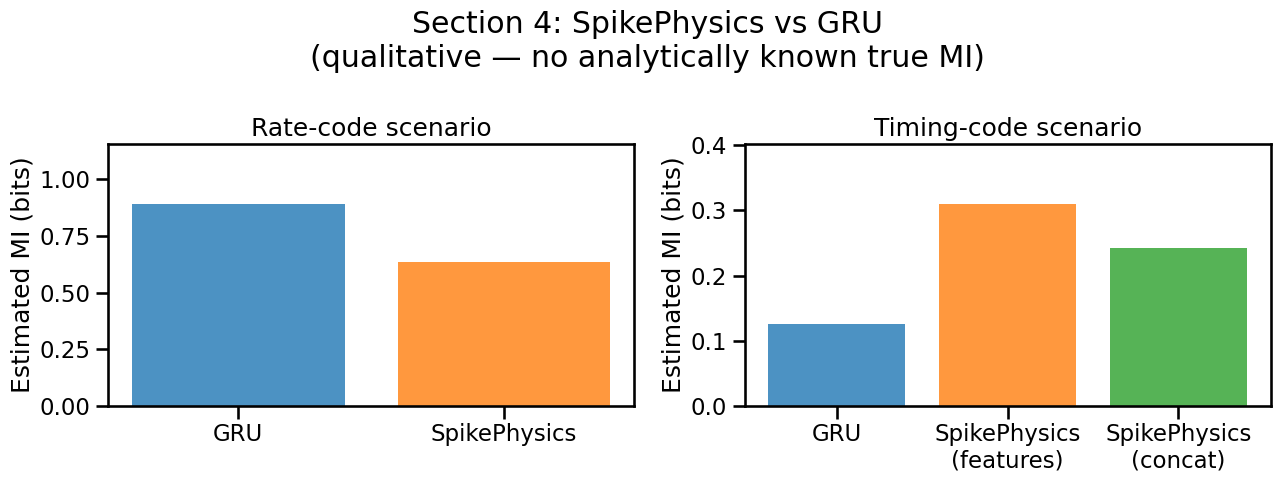

In [23]:
# Summary bar chart for Section 4
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['GRU', 'SpikePhysics'], [gru_rate_mi.mean(), phys_rate_mi.mean()],
            color=['tab:blue', 'tab:orange'], alpha=0.8)
axes[0].set_title('Rate-code scenario')
axes[0].set_ylabel('Estimated MI (bits)')
axes[0].set_ylim(0, max(gru_rate_mi.mean(), phys_rate_mi.mean()) * 1.3)

axes[1].bar(['GRU', 'SpikePhysics\n(features)', 'SpikePhysics\n(concat)'],
            [gru_t.mean(), phys_t.mean(), concat_t.mean()],
            color=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.8)
axes[1].set_title('Timing-code scenario')
axes[1].set_ylabel('Estimated MI (bits)')
axes[1].set_ylim(0, max(gru_t.mean(), phys_t.mean(), concat_t.mean()) * 1.3)

plt.suptitle('Section 4: SpikePhysics vs GRU\n(qualitative — no analytically known true MI)')
plt.tight_layout()
plt.show()

**Interpretation:**

*Rate code:* ``spike_physics`` should perform comparably or better than GRU.
It computes firing rate directly from the spike count — the optimal sufficient
statistic for rate-coded MI — with zero learned parameters in the feature
extraction stage.  The MLP head only needs to learn the projector.

*Timing code:* GRU should outperform ``spike_physics (features)`` because
the four summary statistics (firing rate, mean spike time, ISI mean, ISI var)
are dominated by the 3× background noise and cannot detect the 15 ms latency
correlation.  GRU processes the actual timestamp sequence and can learn to
detect co-firing patterns.

*SpikePhysics (concat):* By concatenating raw spike times alongside the
physics features, the model retains fine timing information while preserving
the efficient physics features.  This hybrid should bridge both scenarios.

**Important caveat:** Results have high variance at N ≈ 800 windows for the
timing-code scenario.  Run multiple seeds and increase duration for more
reliable comparisons in real analyses.

## Section 5: Pretrained Backbone for Image Data

This section has two scenarios that tell a complete, scientifically honest story.

### Scenario A — Alignment (positive case)

MNIST digit pairs (classes 0 and 1) share class identity.  The only shared
information is "which digit is this?" — exactly 1 bit (two balanced classes).
The pretrained ResNet18 backbone has already learned to detect digit-level
structure from ImageNet pretraining, so it encodes class identity immediately.
A CNN2D trained from scratch must discover this structure from the MI data alone.

Note: this section requires ``torchvision``.  Install with:
``pip install neural_mi[vision]``  or  ``pip install torchvision``

Also note: MNIST images are 28×28, but ResNet18 was pretrained on 224×224
images.  Library Fix 2 automatically adds a bilinear upsample layer and emits
a UserWarning — this is expected and does not break training.

### Scenario B — Misalignment (negative control)

Gaussian blobs share a common location, but the location structure is not the
kind of visual feature pretrained ResNet18 detects (edges, textures, objects).
Pretrained features are actively harmful here — they discard the blob location
information.  A CNN2D trained from scratch does better.

Together, the two scenarios make the key point: pretrained backbones only
help when the pretraining domain aligns with the MI-relevant structure.


=== Section 5: Pretrained Backbone — MNIST (Alignment) ===


/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_97162/3510464048.py:26: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  _targets = np.array(_mnist.targets)


MNIST 0 vs 1: 12665 images total
MNIST pair dataset: (1500, 1, 28, 28)   True MI = 1.00 bits


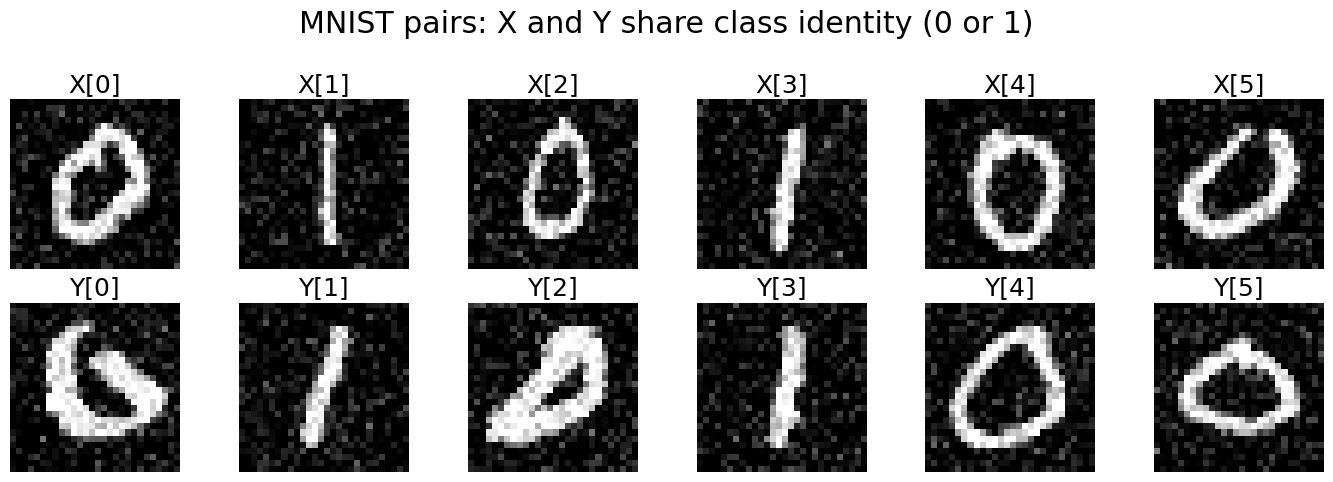


Scenario A — MNIST alignment (warning about 28x28 upsampling is expected):


2026-04-22 17:20:39 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:39 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:39 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:39 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py:371: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was -0.0000 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


  N=  50  CNN2D (random init)             MI=0.559 ± 0.409 bits


2026-04-22 17:20:54 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:54 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:54 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:20:54 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/utils.py:257: UserWarning: PretrainedBackboneEmbedding: input has 1 channel(s) but backbone 'resnet18' expects 3. Adding a trainable 1×1 conv channel adapter.
  net_x_base = EmbeddingModel(input_dim_x, **model_kwargs)
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/utils.py:257: UserWarning: PretrainedBackboneEmbedding: input has 1 channel(s) but backbone 'resnet18' expects 3. Adding a trainable 1×1 conv channel adapter.
  net_x_base = EmbeddingModel(input_dim_x, **model_kwargs)
/Users/eabdelaleem3/Library/CloudStorage

  N=  50  Pretrained ResNet18             MI=0.181 ± 0.539 bits


...

  N= 200  CNN2D (random init)             MI=0.780 ± 0.080 bits


2026-04-22 17:27:07 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:27:07 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:27:07 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:27:07 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/utils.py:257: UserWarning: PretrainedBackboneEmbedding: input has 1 channel(s) but backbone 'resnet18' expects 3. Adding a trainable 1×1 conv channel adapter.
  net_x_base = EmbeddingModel(input_dim_x, **model_kwargs)
/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/utils.py:257: UserWarning: PretrainedBackboneEmbedding: input has 1 channel(s) but backbone 'resnet18' expects 3. Adding a trainable 1×1 conv channel adapter.
  net_x_base = EmbeddingModel(input_dim_x, **model_kwargs)
/Users/eabdelaleem3/Library/CloudStorage

  N= 200  Pretrained ResNet18             MI=1.956 ± 1.309 bits


2026-04-22 17:34:22 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:34:22 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:34:22 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:34:22 - neural_mi - INFO - Created PairedDataset
Process SpawnPoolWorker-28:
Traceback (most recent call last):
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py", line 371, in run_tra

KeyboardInterrupt: 

In [2]:
print("\n=== Section 5: Pretrained Backbone — MNIST (Alignment) ===")

try:
    import torchvision
    import torchvision.transforms as transforms
    _HAS_TORCHVISION = True
except ImportError:
    _HAS_TORCHVISION = False
    print("torchvision not installed. Skipping Scenario A.")
    print("Install with:  pip install torchvision")

if _HAS_TORCHVISION:
    # Load MNIST, keep only digits 0 and 1
    _mnist_root = '/tmp/mnist_data'
    _transform = transforms.ToTensor()
    try:
        _mnist = torchvision.datasets.MNIST(root=_mnist_root, train=True,
                                             download=True, transform=_transform)
    except Exception as _e:
        print(f"Could not download MNIST: {_e}")
        _HAS_TORCHVISION = False

if _HAS_TORCHVISION:
    np.random.seed(500)

    _targets = np.array(_mnist.targets)
    _images = _mnist.data.numpy().astype(np.float32) / 255.0  # (60000, 28, 28)

    # Keep only digits 0 and 1
    _mask = (_targets == 0) | (_targets == 1)
    _imgs_01 = _images[_mask]         # (N_01, 28, 28)
    _labels_01 = _targets[_mask]      # (N_01,)
    print(f"MNIST 0 vs 1: {_imgs_01.shape[0]} images total")

    # Build paired dataset: for each pair (X_i, Y_i), both are same class,
    # different instances, with independent Gaussian noise augmentation
    N_MNIST = 1500
    _noise_std = 0.15

    X_mnist = np.zeros((N_MNIST, 1, 28, 28), dtype=np.float32)
    Y_mnist = np.zeros((N_MNIST, 1, 28, 28), dtype=np.float32)

    for i in range(N_MNIST):
        label = np.random.randint(0, 2)
        _class_imgs = _imgs_01[_labels_01 == label]
        idx_x, idx_y = np.random.choice(len(_class_imgs), 2, replace=True)
        X_mnist[i, 0] = _class_imgs[idx_x] + _noise_std * np.random.randn(28, 28)
        Y_mnist[i, 0] = _class_imgs[idx_y] + _noise_std * np.random.randn(28, 28)

    X_mnist = np.clip(X_mnist, 0.0, 1.0)
    Y_mnist = np.clip(Y_mnist, 0.0, 1.0)

    TRUE_MI_MNIST = 1.0  # log2(2) = 1 bit, two balanced classes
    print(f"MNIST pair dataset: {X_mnist.shape}   True MI = {TRUE_MI_MNIST:.2f} bits")

    # Visualise a few pairs
    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for j in range(6):
        axes[0, j].imshow(X_mnist[j, 0], cmap='gray', vmin=0, vmax=1)
        axes[0, j].set_title(f'X[{j}]'); axes[0, j].axis('off')
        axes[1, j].imshow(Y_mnist[j, 0], cmap='gray', vmin=0, vmax=1)
        axes[1, j].set_title(f'Y[{j}]'); axes[1, j].axis('off')
    plt.suptitle('MNIST pairs: X and Y share class identity (0 or 1)')
    plt.tight_layout()
    plt.show()

    N_VALUES_IMG = [50, 100, 200, 400, 800, 1500]
    IMG_PARAMS = {**BASE_TRAIN, 'n_epochs': 200, 'patience': 40}

    models_mnist = [
        ('CNN2D (random init)', {'embedding_model': 'cnn2d'}),
        ('Pretrained ResNet18',  {'embedding_model': 'pretrained_backbone',
                                  'pytorch_predefined': 'resnet18', 'pretrained': True}),
    ]

    print("\nScenario A — MNIST alignment (warning about 28x28 upsampling is expected):")
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        df_mnist = run_sample_efficiency(
            X_mnist, Y_mnist, N_VALUES_IMG, models_mnist, TRUE_MI_MNIST,
            base_train=IMG_PARAMS,
        )
    upsample_warnings = [w for w in caught if 'spatial size' in str(w.message).lower()]
    if upsample_warnings:
        print(f"  [Expected] Backbone upsample warning: {str(upsample_warnings[0].message)[:120]}...")

    fig, ax = plt.subplots(figsize=(9, 5))
    print("\nCrossover N values (Scenario A — MNIST):")
    plot_sample_efficiency(df_mnist, TRUE_MI_MNIST,
                           'Section 5A: Pretrained Backbone — MNIST (Alignment)', ax=ax)
    plt.tight_layout()
    plt.show()

In [2]:
# --- Scenario B: Gaussian blobs (misalignment / negative control) ---
print("\n=== Section 5B: Pretrained Backbone — Gaussian Blobs (Misalignment) ===")

np.random.seed(600)
N_BLOBS = 800

X_blobs, Y_blobs = nmi.generators.generate_noisy_image_pairs(
    n_samples=N_BLOBS, image_size=64, n_channels=3,
    signal_strength=2.5, noise_level=1.0, use_torch=False,
)
# Use 5000-window empirical MI as reference (single Gaussian blob is a
# high-dimensional correlated pair; true MI is not analytically known)
# We run a large-N estimate with CNN2D as a reference upper bound
print("Computing reference MI for Gaussian blobs via large-N CNN2D estimate...")
result_blob_ref = nmi.run(
    x_data=X_blobs, y_data=Y_blobs,
    mode='estimate',
    split_mode='random',
    base_params={**BASE_TRAIN, 'n_epochs': 200, 'embedding_model': 'cnn2d'},
    random_seed=0, show_progress=True,
)
ref_mi_blobs = result_blob_ref.mi_estimate
print(f"Reference MI (CNN2D, N={N_BLOBS}): {ref_mi_blobs:.3f} bits")

N_VALUES_BLOBS = [50, 100, 200, 400, 800]
models_blobs = [
    ('CNN2D (random init)', {'embedding_model': 'cnn2d'}),
    ('Pretrained ResNet18',  {'embedding_model': 'pretrained_backbone',
                              'pytorch_predefined': 'resnet18', 'pretrained': True}),
]

print("\nScenario B — Gaussian blobs (misalignment control):")
df_blobs = run_sample_efficiency(
    X_blobs, Y_blobs, N_VALUES_BLOBS, models_blobs, ref_mi_blobs,
    base_train=BASE_TRAIN,
)

fig, ax = plt.subplots(figsize=(9, 5))
print("\nCrossover N values (Scenario B — blobs):")
plot_sample_efficiency(df_blobs, ref_mi_blobs,
                       'Section 5B: Pretrained Backbone — Gaussian Blobs (Misalignment)',
                       ax=ax)
ax.set_title('Section 5B: Gaussian Blobs (Misalignment)\n'
             'Dashed line = CNN2D reference estimate (not analytically exact)')
plt.tight_layout()
plt.show()


=== Section 5B: Pretrained Backbone — Gaussian Blobs (Misalignment) ===
Computing reference MI for Gaussian blobs via large-N CNN2D estimate...


Sequential Sweep Progress: 100%|██████████| 1/1 [01:48<00:00, 108.88s/it]

Reference MI (CNN2D, N=800): 3.142 bits

Scenario B — Gaussian blobs (misalignment control):



/var/folders/2l/ltx3g97s0xs9n9x3w0z40n4w0000gs/T/ipykernel_70891/3064343926.py:33: UserWarning: Very few samples detected (50 samples). Neural MI estimators are prone to overfitting at this scale. Consider adding regularisation (dropout, norm_layer) in base_params.
  df_blobs = run_sample_efficiency(
2026-04-22 16:37:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:37:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:37:30 - neural_mi - INFO - Created PairedDataset
2026-04-22 16:37:30 - neural_mi - INFO - Created PairedDataset


  N=  50  CNN2D (random init)             MI=1.879 ± 0.078 bits


...

  N= 400  CNN2D (random init)             MI=2.954 ± 0.037 bits


2026-04-22 17:02:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:02:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:02:14 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:02:14 - neural_mi - INFO - Created PairedDataset
/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/site-packages/torch/nn/modules/module.py:1790: UserWarning: PretrainedBackboneEmbedding: input spatial size (64×64) does not match the expected size (224×224). Adding a bilinear upsample layer. This may reduce the quality of pretrained features at very small input sizes but is generally acceptable.
  return forward_call(*args, **kwargs)
/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/site-packages/torch/nn/modules/module.py:1790: UserWarning: PretrainedBackboneEmbedding: input spatial size (64×64) does not match the expected size (224×224). Adding a bilinear upsample layer. This may reduce the quality of pretrained features at very sm

  N= 400  Pretrained ResNet18             MI=0.188 ± 0.372 bits


2026-04-22 17:10:35 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:10:35 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:10:35 - neural_mi - INFO - Created PairedDataset
2026-04-22 17:10:35 - neural_mi - INFO - Created PairedDataset
Process SpawnPoolWorker-35:
Traceback (most recent call last):
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/eabdelaleem3/anaconda3/envs/neuralmi_upgrading_april21/lib/python3.10/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/Users/eabdelaleem3/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/Postdoc Projects/NeuralMI-Updating_21April2026/neural_mi/analysis/task.py", line 371, in run_tra

KeyboardInterrupt: 

**Interpretation:**

*Scenario A (MNIST):* With pretrained=True, the backbone should reach the
1.0 bit true MI at much lower N than CNN2D from scratch.  The pretrained
ResNet18 already encodes digit identity — it needs only the MLP head to be
trained on the MI task.

*Scenario B (Gaussian blobs):* The pretrained backbone performs worse than
CNN2D trained from scratch.  The ImageNet-pretrained features detect edges,
textures, and object-level structure — none of which exists in Gaussian blobs.
The pretrained backbone is discarding the blob location signal that CNN2D
can find directly.

**Lesson:** Pretrained backbones require alignment between the pretraining
domain and the MI-relevant structure.  Always run Scenario B as a sanity check
when using pretrained_backbone on new data.  If pretrained performs worse than
random init, your data structure does not match the pretrained features.

Also note: the 28×28 → 224×224 bilinear upsampling (Library Fix 2) should
have emitted a UserWarning above.  The warning is informational — training
proceeds normally.  Very small images may have reduced feature quality, but
for MNIST digit classification the upsampling is sufficient.

## Summary

| Section | Data | Baseline | Biased model | Expected crossover advantage |
|---------|------|----------|--------------|------------------------------|
| 1 | Multi-channel oscillatory (8 ch, different frequencies) | CNN | CNN depthwise | Depthwise lower crossover N |
| 2 | Alpha-band LFP (10 Hz) | CNN | SincCNN | SincCNN lower crossover N |
| 3 | GCaMP fluorescence | CNN | CalciumCNN | CalciumCNN lower crossover N |
| 4 (rate) | Rate-modulated spikes | GRU | SpikePhysics | SpikePhysics ≥ GRU |
| 4 (timing) | Signal spikes in noise | GRU | SpikePhysics | GRU > SpikePhysics |
| 5A | MNIST digits 0/1 | CNN2D random | ResNet18 pretrained | Pretrained lower crossover N |
| 5B | Gaussian blobs | CNN2D random | ResNet18 pretrained | CNN2D random wins (misalignment) |

The core message: **inductive biases lower sample complexity when the bias
matches the data structure, and are either neutral or harmful when it does not.**
Measuring sample efficiency curves with known ground-truth MI is the principled
way to validate this claim quantitatively.